# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [1]:
import pandas as pd

aisles = pd.read_csv('./datos/aisles.csv', sep=';')
departments = pd.read_csv('./datos/departments.csv', sep=';')
instacart_orders = pd.read_csv('./datos/instacart_orders.csv', sep=';')
order_products = pd.read_csv('./datos/order_products.csv', sep=';')
products = pd.read_csv('./datos/products.csv', sep=';')

databases = {
    'aisles': aisles,
    'departments': departments,
    'instacart_orders': instacart_orders,
    'order_products': order_products,
    'products': products
}

In [2]:
for name, df in databases.items():
    print("-" * 100)
    print(f"DataFrame: {name}")
    print("\n")

    print("Head:")
    display(df.head())
    print("\n")
    
    print("Info:")
    display(df.info(show_counts=True))
    print("\n")

    print("Sample:")
    display(df.sample(5, random_state=1))
    print("\n")

----------------------------------------------------------------------------------------------------
DataFrame: aisles


Head:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation




Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


None



Sample:


...

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13




Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


None



Sample:


,product_id,product_name,aisle_id,department_id
20471,20472,NaN,100,21
34022,34023,Whole Grain Quinoa,63,9
33304,33305,Brooklyn Blackout Cake Ice Cream,37,1
11809,11810,NaN,100,21
25065,25066,Dark Hazelnut Praline Square,45,19


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

En la primera radiografía del dataset se observan varios hallazgos sobre la calidad de los datos:

- Los IDs en todas las tablas están correctamente en `int64`.
- `order_dow` y `order_hour_of_day` están en `int64` lo cual es correcto en este caso ya que son números enteros, aunque se los trata como variables o medidas y no como dimensiones.
- `add_to_cart_order` y `days_since_prior_order` aparecen como `float64` cuando en la realidad deberían ser enteros. Esto sugiere una posible presencia de valores nulos.
- En `products`, `product_name` tiene nulos (48436/49694 no nulos).
- En `order_products`, `add_to_cart_order ` tiene nulos (4544171/4545007 no nulos)
- En `instacart_orders`, `days_since_prior_order` tiene nulos (450148/478967 no nulos).
- El volumen es alto y adecuado para EDA robusto (`order_products` > 4.5M filas), pero exige limpieza previa antes de inferencias.
- La estructura relacional entre tablas luce consistente para construir una OBT.

Opino que es un dataset útil y bien estructurado, pero requiere una revisión profunda y limpieza antes de modelar u obtener análisis detallados.

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [3]:
for name, df in databases.items():
    print(f"DataFrame: {name}, duplicated rows: {df.duplicated().sum()}")

DataFrame: aisles, duplicated rows: 0
DataFrame: departments, duplicated rows: 0
DataFrame: instacart_orders, duplicated rows: 15
DataFrame: order_products, duplicated rows: 0
DataFrame: products, duplicated rows: 0


In [4]:
duplicated_orders = instacart_orders[instacart_orders.duplicated()]
display(duplicated_orders)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Observamos que en todos los registros duplicados se repite `order_dow == 3` y `order_hour_of_day == 2`.

In [5]:
print(f'Días de la semana con duplicados: {duplicated_orders["order_dow"].unique()}')
print(f'Horas del día con duplicados: {duplicated_orders["order_hour_of_day"].unique()}')

Días de la semana con duplicados: [3]
Horas del día con duplicados: [2]


Verificamos si existen filas no duplicadas con `order_dow == 3` y `order_hour_of_day == 2`

In [6]:
mask = (instacart_orders['order_dow'] == 3) & \
       (instacart_orders['order_hour_of_day'] == 2) & \
       (~instacart_orders.duplicated(keep=False))

print(f'Número de filas no duplicadas con order_dow=3 y order_hour_of_day=2: {instacart_orders[mask].shape[0]}')
display(instacart_orders[mask].head())

Número de filas no duplicadas con order_dow=3 y order_hour_of_day=2: 91


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0


In [7]:
instacart_orders.drop_duplicates(inplace=True)
print(f'Número de filas después de eliminar duplicados: {instacart_orders.shape[0]}')
print(f'Número de filas duplicadas después de eliminar duplicados: {instacart_orders.duplicated().sum()}')

Número de filas después de eliminar duplicados: 478952
Número de filas duplicadas después de eliminar duplicados: 0


In [8]:
# Buscamos tricky duplicates, es decir, filas que no son exactamente iguales pero que podrían representar el mismo pedido.

print(f'Número de order_id duplicados: {instacart_orders["order_id"].duplicated().sum()}')

Número de order_id duplicados: 0


In [9]:
# Buscamos tricky duplicates, es decir, filas que no son exactamente iguales pero que podrían representar el mismo pedido.

id_cols = {
    'aisles': 'aisle_id',
    'departments': 'department_id',
    'instacart_orders': 'order_id',
    'products': 'product_id'
}

for name, id_col in id_cols.items():
    df = databases[name]
    duplicated_ids = df[df[id_col].duplicated()][id_col].unique()
    print(f'DataFrame: {name}, duplicated {id_col}: {duplicated_ids}')

DataFrame: aisles, duplicated aisle_id: []
DataFrame: departments, duplicated department_id: []
DataFrame: instacart_orders, duplicated order_id: []
DataFrame: products, duplicated product_id: []


In [10]:
# Revisamos si hay combinaciones de order_id y product_id que se repiten (esto no necesariamente indica un error, pero es algo a revisar)
(order_products['order_id'].astype(str)+'-'+order_products['product_id'].astype(str)).duplicated().sum()

np.int64(0)

In [11]:
# Revisamos duplicados por nombre de producto
duplicated_product_names = products[(products['product_name'].str.lower().duplicated()) & (~products['product_name'].isna())]
duplicated_product_names.loc[:, 'product_name'] = duplicated_product_names['product_name'].str.lower()
duplicated_product_names.head()

,product_id,product_name,aisle_id,department_id
2058,2059,biotin 1000 mcg,47,11
5455,5456,green tea with ginseng and honey,96,20
5558,5559,cream of mushroom soup,69,15
7558,7559,cinnamon rolls with icing,105,13
9037,9038,american cheese slices,21,16


### Conclusiones sobre la Precisión:
Explica por qué eliminaste (o consolidaste) la información y qué nos enseña sobre la ingesta del sistema.

Notemos que varias todas las filas duplicadas cuentan con `order_dow == 3` y `order_hour_of_day == 2`, pero no todas las filas con esos valores son duplicadas, por lo que los duplicados son aleatorios y se concluye que se deben eliminar. Así mismo, después de eliminar duplicados de filas, quedamos sin tricky duplicates al igual que en el resto de tablas no contamos con tricky duplicates.

Por otro lado, los duplicados de `product_name` no podemos borrarlos ya que cuentan con ids diferentes para las demás columnas.

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [12]:
# Resumen compacto de valores nulos por tabla y columna
null_summary = []

for name, df in databases.items():
    for column in df.columns:
        null_count = df[column].isna().sum()
        if null_count > 0:
            null_summary.append({
                "dataframe": name,
                "column": column,
                "null_count": int(null_count),
                "null_pct": round(null_count / len(df) * 100, 2)
            })

null_summary = pd.DataFrame(null_summary)
display(null_summary)

,dataframe,column,null_count,null_pct
0,instacart_orders,days_since_prior_order,28817,6.02
1,order_products,add_to_cart_order,836,0.02
2,products,product_name,1258,2.53


In [13]:
# Nombres de productos vacíos

empty_product_names = products[products['product_name'].isna()]
empty_product_names.sample(5,random_state=1)

,product_id,product_name,aisle_id,department_id
40401,40402,NaN,100,21
37201,37202,NaN,100,21
11824,11825,NaN,100,21
21921,21922,NaN,100,21
38804,38805,NaN,100,21


In [14]:
print(f'Pasillos con valores nulos: {empty_product_names["aisle_id"].unique()}')
print(f'Departamentos con valores nulos: {empty_product_names["department_id"].unique()}')

Pasillos con valores nulos: [100]
Departamentos con valores nulos: [21]


Observamos que todos los productos con nombre nulo contienen `aisle_id == 100` y `department_id == 21`.

In [15]:
mask = (products['aisle_id'] == 100) & (products['department_id'] == 21) & (~products['product_name'].isna())

print(f'Número de productos con aisle_id=100, department_id=21 y product_name no nulo: {products[mask].shape[0]}')
products[mask].head()

Número de productos con aisle_id=100, department_id=21 y product_name no nulo: 0


,product_id,product_name,aisle_id,department_id


Así mismo, todos los productos con `aisle_id == 100` y `department_id == 21` contienen un nombre nulo, indicando un error en el sistema al momento de registrar los productos en la base.

In [16]:
# no podemos eliminarlos, entonces imputamos un valor por defecto

products['product_name'].fillna('Unknown Product', inplace=True)
products[products['product_name'] == 'Unknown Product'].head()

,product_id,product_name,aisle_id,department_id
37,38,Unknown Product,100,21
71,72,Unknown Product,100,21
109,110,Unknown Product,100,21
296,297,Unknown Product,100,21
416,417,Unknown Product,100,21


In [17]:
print(f'Número de productos con nombre nulo: {products[products["product_name"].isna()].shape[0]}')

Número de productos con nombre nulo: 0


In [18]:
# Orden de agregado al carrito nulo

nulls_add_to_cart = order_products[order_products['add_to_cart_order'].isna()]
print(f'Número de filas con add_to_cart_order nulo: {nulls_add_to_cart.shape[0]}')
display(nulls_add_to_cart.sample(5, random_state=1))
display(order_products.describe().iloc[1:])

Número de filas con add_to_cart_order nulo: 836


,order_id,product_id,add_to_cart_order,reordered
4443007,1968313,22497,NaN,0
1366404,2997021,4896,NaN,0
1260501,3308010,33929,NaN,1
4376957,1968313,5605,NaN,0
1162827,3308010,12741,NaN,1


,order_id,product_id,add_to_cart_order,reordered
mean,1.711166e+06,25580.835682,8.351669,0.590503
std,9.850955e+05,14095.518725,7.080368,0.491741
min,4.000000e+00,1.000000,1.000000,0.000000
25%,8.608170e+05,13535.000000,3.000000,0.000000
50%,1.711530e+06,25272.000000,6.000000,1.000000
75%,2.561311e+06,37935.000000,11.000000,1.000000
max,3.421079e+06,49694.000000,64.000000,1.000000


A simple vista no se evidencia un patrón en `add_to_cart_order` nulos, pero podemos revisar la cantidad de productos que contiene cada orden

In [19]:
order_products_copy = order_products.copy()
product_count = order_products_copy.groupby('order_id')['product_id'].count().rename('product_count').reset_index()
display(product_count.head())

order_products_copy = order_products_copy.merge(product_count, on='order_id', how='left')
display(order_products_copy.head())
display(order_products_copy.describe().iloc[1:])

,order_id,product_count
0,4,13
1,9,15
2,11,5
3,19,3
4,20,8


,order_id,product_id,add_to_cart_order,reordered,product_count
0,2141543,11440,17.0,0,20
1,567889,1560,1.0,1,26
2,2261212,26683,1.0,1,14
3,491251,8670,35.0,1,42
4,2571142,1940,5.0,1,12


,order_id,product_id,add_to_cart_order,reordered,product_count
mean,1.711166e+06,25580.835682,8.351669,0.590503,15.728717
std,9.850955e+05,14095.518725,7.080368,0.491741,9.564469
min,4.000000e+00,1.000000,1.000000,0.000000,1.000000
25%,8.608170e+05,13535.000000,3.000000,0.000000,9.000000
50%,1.711530e+06,25272.000000,6.000000,1.000000,14.000000
75%,2.561311e+06,37935.000000,11.000000,1.000000,21.000000
max,3.421079e+06,49694.000000,64.000000,1.000000,127.000000


Ahora podemos notar que `add_to_cart_order` tiene como valor máximo 64 pese a que al contar los productos tenemos que llegan hasta 127, indicando un posible error a partir de 64.

In [20]:
# Repetimos análisis

orders_with_nulls = order_products_copy[order_products_copy['add_to_cart_order'].isna()]['order_id'].unique()

print("Descripción de filas con al menos un producto con add_to_cart_order nulo en la orden:")
display(order_products_copy[order_products_copy['order_id'].isin(orders_with_nulls)].describe().iloc[1:])

print("Descripción de filas sin productos con add_to_cart_order nulo en la orden:")
display(order_products_copy[~order_products_copy['order_id'].isin(orders_with_nulls)].describe().iloc[1:])

Descripción de filas con al menos un producto con add_to_cart_order nulo en la orden:


,order_id,product_id,add_to_cart_order,reordered,product_count
mean,1.599895e+06,25146.709744,32.500000,0.619639,78.102333
std,9.481167e+05,14335.784892,18.475015,0.485521,14.476245
min,9.310000e+03,10.000000,1.000000,0.000000,65.000000
25%,8.546470e+05,12960.250000,16.750000,0.000000,68.000000
50%,1.648217e+06,25146.000000,32.500000,1.000000,73.000000
75%,2.409109e+06,37646.000000,48.250000,1.000000,86.000000
max,3.383594e+06,49683.000000,64.000000,1.000000,127.000000


Descripción de filas sin productos con add_to_cart_order nulo en la orden:


,order_id,product_id,add_to_cart_order,reordered,product_count
mean,1.711296e+06,25581.344045,8.327839,0.590468,15.655677
std,9.851307e+05,14095.228740,7.019136,0.491747,9.315565
min,4.000000e+00,1.000000,1.000000,0.000000,1.000000
25%,8.608230e+05,13535.000000,3.000000,0.000000,9.000000
50%,1.711684e+06,25272.000000,6.000000,1.000000,14.000000
75%,2.561474e+06,37935.000000,11.000000,1.000000,21.000000
max,3.421079e+06,49694.000000,64.000000,1.000000,64.000000


Con esto podemos verificar que todas las órdenes con valores nulos en `add_to_cart_order` cuentan con 65 productos o más en el carrito, al igual que todas las órdenes sin nulos es porque tienen 64 productos o menos.

In [21]:
order_products.fillna({'add_to_cart_order': -1}, inplace=True)

print(f'Número de filas con add_to_cart_order nulo después de imputar: {order_products["add_to_cart_order"].isna().sum()}')

Número de filas con add_to_cart_order nulo después de imputar: 0


In [22]:
# Días desde último pedido nulos

empty_days_since_prior_order = instacart_orders[instacart_orders['days_since_prior_order'].isna()]
print(f'Número de filas con days_since_prior_order nulo: {empty_days_since_prior_order.shape[0]}')
display(empty_days_since_prior_order.sample(5, random_state=1))

Número de filas con days_since_prior_order nulo: 28817


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
27757,2971010,45664,1,4,9,NaN
375265,2902531,103522,1,3,15,NaN
243431,2843891,15466,1,6,16,NaN
98945,3240610,147389,1,1,8,NaN
446520,2702253,114531,1,6,14,NaN


In [23]:
order_numbers_with_nulls = empty_days_since_prior_order['order_number'].unique()

print(f'Números de orden con days_since_prior_order nulos: {order_numbers_with_nulls}')

Números de orden con days_since_prior_order nulos: [1]


In [24]:
order_numbers_with_no_nulls = instacart_orders[~instacart_orders['days_since_prior_order'].isna()]['order_number'].unique()

print(f'Número de orden mínimo con days_since_prior_order sin valores nulos: {order_numbers_with_no_nulls.min()}')

Número de orden mínimo con days_since_prior_order sin valores nulos: 2


Comprobamos que todas las órdenes con `days_since_prior_order` nulo corresponden a la primera órden lo cual es lógico ya que no cuentan con una órden anterior. Por ello imputamos con -1

In [25]:
instacart_orders.fillna({'days_since_prior_order': -1}, inplace=True)

print(f'Número de filas con days_since_prior_order nulo después de imputar: {instacart_orders["days_since_prior_order"].isna().sum()}')

Número de filas con days_since_prior_order nulo después de imputar: 0


### Conclusiones sobre la Completitud:
Argumenta qué mecanismo de ausencia (Rubin) encontraste en cada escenario y por qué tus estrategias de imputación no generaron sesgos severos.

- **`product_name` en `products`**: los nulos se concentran en todos los que contienen `aisle_id = 100` y `department_id = 21`, por lo que el mecanismo es **MAR (Missing At Random)** ya que depende de otras variables. Se imputó **`"Unknown Product"`** para mantener integridad referencial sin alterar IDs ni variables de comportamiento; el sesgo es bajo porque solo se completa una etiqueta descriptiva.
- **`days_since_prior_order` en `instacart_orders`**: los nulos aparecen únicamente cuando `order_number = 1`, así que también corresponde a **MAR** por lo que el faltante está explicado por una variable observada. Mantiene lógica del negocio ya que en la primera compra no existe orden previa. Imputar **`-1`** como indicador conserva la semántica de “primera compra” y evita confundirlo con días reales.
- **`add_to_cart_order` en `order_products`**: los nulos se observan en órdenes grandes ($\geq 65$ ítems) y reflejan un truncamiento del sistema tras 64 posiciones; aquí el mecanismo es **MNAR (Missing Not At Random)** porque la ausencia depende del valor real no observado (posición $> 64$). Se imputó **`-1`** como marcador de desconocido para no inventar un orden artificial y preservar las filas para análisis de recompra.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

In [26]:
# Sensibilidad de days_since_prior_order

days_sensitivity = instacart_orders[instacart_orders['days_since_prior_order']>=0]['days_since_prior_order']
display(days_sensitivity.describe())

count    450135.000000
mean         11.101814
std           9.190004
min           0.000000
25%           4.000000
50%           7.000000
75%          15.000000
max          30.000000
Name: days_since_prior_order, dtype: float64

<Axes: title={'center': 'Boxplot de días desde el último pedido (sin valores nulos)'}>

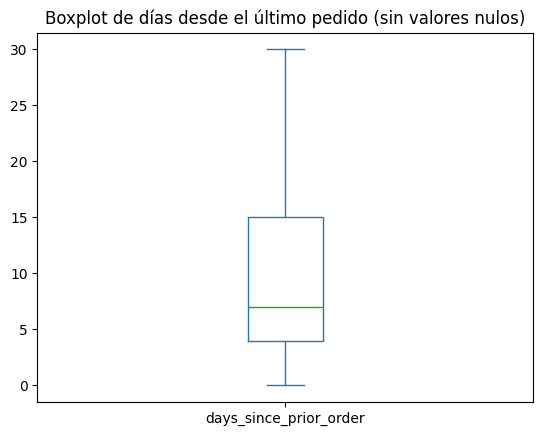

In [27]:
days_sensitivity.plot(kind='box', title='Boxplot de días desde el último pedido (sin valores nulos)')

A simple vista con el gráfico no se observan valores atípicos.

In [28]:
Q1_value = days_sensitivity.quantile(0.25)
Q3_value = days_sensitivity.quantile(0.75)
IQR = Q3_value - Q1_value
lower_bound = Q1_value - 1.5 * IQR
upper_bound = Q3_value + 1.5 * IQR

outliers_days_IQR = days_sensitivity[(days_sensitivity < lower_bound) | (days_sensitivity > upper_bound)]

print(f'Número de valores atípicos con IQR: {outliers_days_IQR.shape[0]}')

Número de valores atípicos con IQR: 0


<Axes: title={'center': 'Distribución de días desde el último pedido (sin nulos)'}, ylabel='Frequency'>

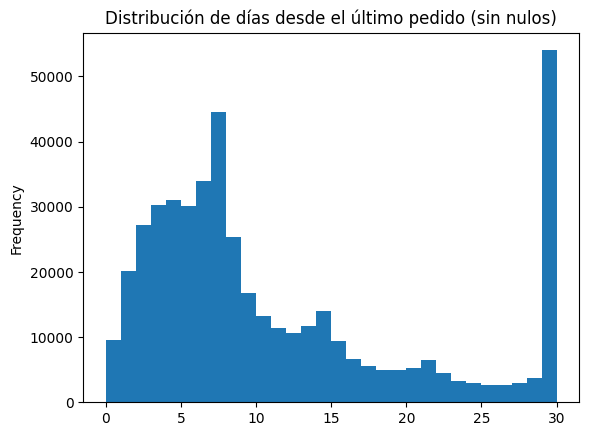

In [29]:
days_sensitivity.plot(kind='hist', bins=30, title='Distribución de días desde el último pedido (sin nulos)')

In [30]:
outliers_days_Z_score = days_sensitivity[abs((days_sensitivity - days_sensitivity.mean()) / days_sensitivity.std()) > 3]

print(f'Número de valores atípicos con Z-score: {outliers_days_Z_score.shape[0]}')

Número de valores atípicos con Z-score: 0


In [31]:
# Sensibilidad de order_number

order_sensitivity = instacart_orders['order_number']
display(order_sensitivity.describe())

count    478952.000000
mean         17.157563
std          17.704457
min           1.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         100.000000
Name: order_number, dtype: float64

<Axes: title={'center': 'Boxplot de order_number (sin valores nulos)'}>

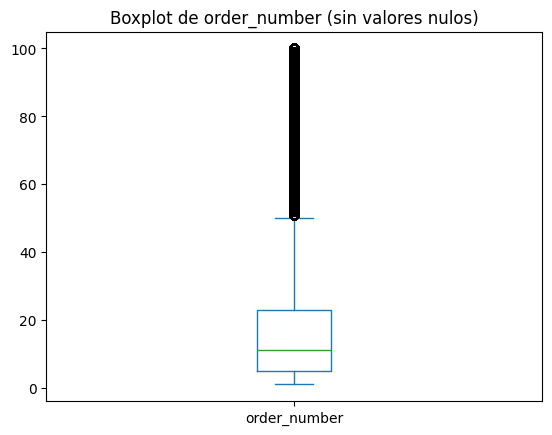

In [32]:
order_sensitivity.plot(kind='box', title='Boxplot de order_number (sin valores nulos)')

In [33]:
number_of_orders = (
    instacart_orders.groupby('user_id')
    .agg(
        max_order_number=('order_number', 'max'),
        number_of_orders=('order_id', 'count')
    )
    .reset_index()
)
number_of_orders.head()

,user_id,max_order_number,number_of_orders
0,2,4,2
1,4,6,2
2,5,4,1
3,6,4,2
4,7,19,2


In [34]:
number_of_orders[number_of_orders['max_order_number'] < number_of_orders['number_of_orders']].shape[0]

0

Debido a que la cantidad de órdenes es menor al número máximo de órdenes que nos indica la base de datos, se sospecha que podemos contener solamente una muestra de todo el universo de órdenes. Esto implica que no podemos verificar correctamente la cantidad de pedidos por usuario; sin embargo, se realiza el análisis para validar si tenemos casos de usuarios con cantidad atípica de órdenes.

In [35]:
number_of_orders['number_of_orders'].value_counts()

number_of_orders
1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
11     1308
12      947
13      703
14      512
15      437
16      263
17      184
18      121
19       85
20       52
22       23
21       22
23       19
24        3
25        1
28        1
26        1
Name: count, dtype: int64

In [36]:
number_of_orders['max_order_number'].value_counts()

max_order_number
4     12368
3     10510
5     10406
6      9194
2      9113
      ...  
81       89
84       87
80       86
89       85
87       76
Name: count, Length: 100, dtype: int64

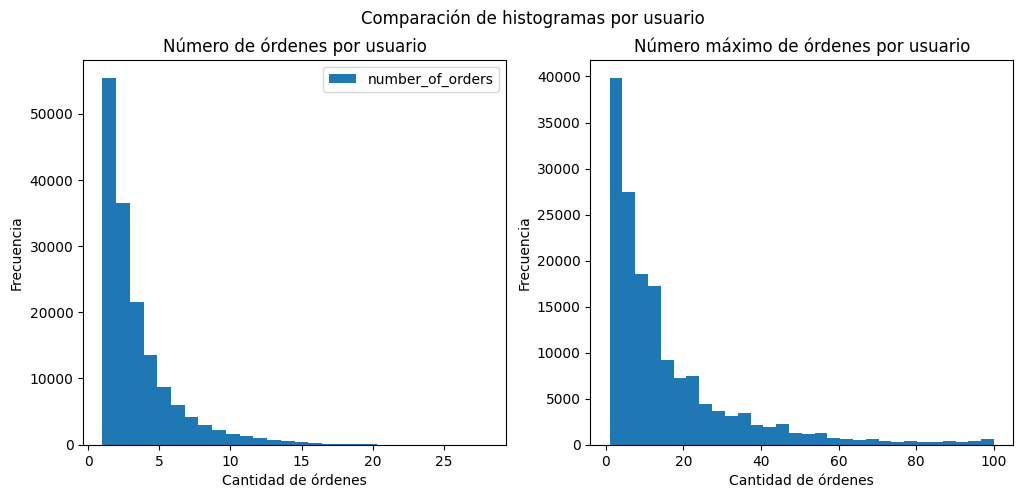

In [37]:
import numpy as np

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(number_of_orders['number_of_orders'], bins=number_of_orders['number_of_orders'].max(), label='number_of_orders')
axes[1].hist(number_of_orders['max_order_number'], bins=30, label='max_order_number')

axes[0].set_title('Número de órdenes por usuario')
axes[1].set_title('Número máximo de órdenes por usuario')
axes[0].set_xlabel('Cantidad de órdenes')
axes[1].set_xlabel('Cantidad de órdenes')
axes[0].set_ylabel('Frecuencia')
axes[1].set_ylabel('Frecuencia')
axes[0].figure.suptitle('Comparación de histogramas por usuario')

ax = axes[0]
ax.legend()

Notamos que en ambas se observa una distribución bastante razonable

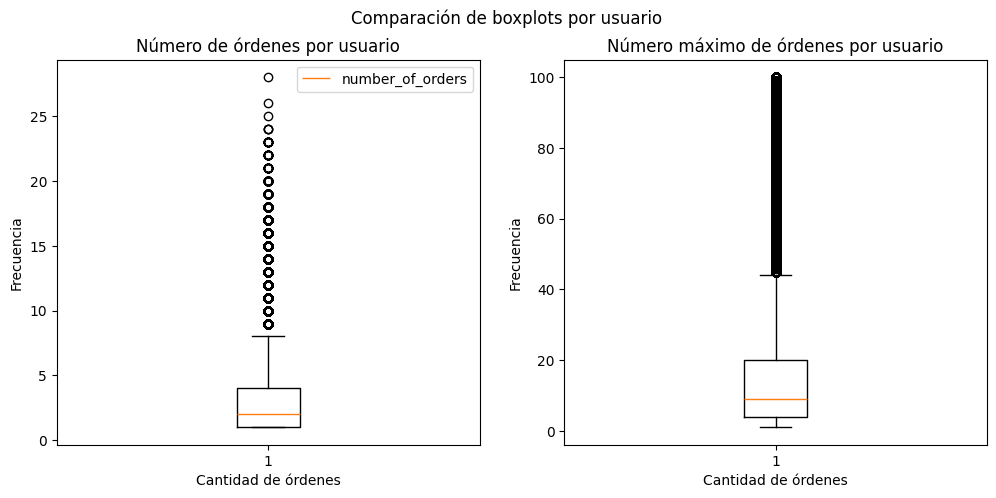

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(number_of_orders['number_of_orders'], label='number_of_orders')
axes[1].boxplot(number_of_orders['max_order_number'], label='max_order_number')

axes[0].set_title('Número de órdenes por usuario')
axes[1].set_title('Número máximo de órdenes por usuario')
axes[0].set_xlabel('Cantidad de órdenes')
axes[1].set_xlabel('Cantidad de órdenes')
axes[0].set_ylabel('Frecuencia')
axes[1].set_ylabel('Frecuencia')
axes[0].figure.suptitle('Comparación de boxplots por usuario')

ax = axes[0]
ax.legend()

Hay una alta concentración de valores bajos, por lo que los valores más altos se consideran atípicos

In [39]:
# analisis IQR y z-score para ambos

for col in ['number_of_orders', 'max_order_number']:
    Q1_value = number_of_orders[col].quantile(0.25)
    Q3_value = number_of_orders[col].quantile(0.75)
    IQR = Q3_value - Q1_value
    lower_bound = Q1_value - 1.5 * IQR
    upper_bound = Q3_value + 1.5 * IQR

    outliers_IQR = number_of_orders[(number_of_orders[col] < lower_bound) | (number_of_orders[col] > upper_bound)]
    print(f'Número de valores atípicos en {col} con IQR: {outliers_IQR.shape[0]}')

    z_scores = (number_of_orders[col] - number_of_orders[col].mean()) / number_of_orders[col].std()
    outliers_Z_score = number_of_orders[abs(z_scores) > 3]
    print(f'Número de valores atípicos en {col} con Z-score: {outliers_Z_score.shape[0]}')

Número de valores atípicos en number_of_orders con IQR: 8479
Número de valores atípicos en number_of_orders con Z-score: 3374
Número de valores atípicos en max_order_number con IQR: 11336
Número de valores atípicos en max_order_number con Z-score: 3865


### Conclusiones sobre la Sensibilidad:
En cuanto a `days_since_prior_order`, se concluye que no hay datos atípicos, aunque es extraño que hayan tantas filas con valor 30, ajeno al resto de la distribución y probablemente indicando que esos valores deberían ser mayores pero se limitaron a 30. 

Por otro lado, para el número de órdenes tenemos 2 perspectivas, `number_of_orders` correspondiente al conteo de órdenes por usuario, y `max_order_number` correspondiente a la orden con valor máximo de `order_number` por usuario. Para ambas variables, la distribución en la vista del histograma se ve lógica con un comportamiento logarítmico o una distribución sesgada a la derecha. Al analizar por IQR o Z-score, se obtienen varios valores atípicos pero es debido a que la frecuencia disminuye conforme aumenta la cantidad de órdenes. Por este motivo no se toma ninguna acción sobre la base de datos.

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [40]:
order_products['order_id'].nunique(), instacart_orders['order_id'].nunique()

(450046, 478952)

In [41]:
(~order_products['order_id'].isin(instacart_orders['order_id'].unique())).sum()

np.int64(0)

In [42]:
(~instacart_orders['order_id'].isin(order_products['order_id'].unique())).sum()

np.int64(28906)

Todas las órdenes de `order_products` están en `instacart_orders`, pero no viceversa, por lo cual nuestra tabla principal debe ser la que contenga más información y juntar con left joins.

In [43]:
obt = instacart_orders.copy()
obt = obt.merge(order_products, on='order_id', how='left')
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4545007 non-null  float64
 7   add_to_cart_order       4545007 non-null  float64
 8   reordered               4545007 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 314.1 MB


In [44]:
obt[obt['product_id'].isna()].sample(10, random_state=1)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
3262889,2514147,169803,26,4,23,2.0,NaN,NaN,NaN
632576,1364493,10417,13,3,14,8.0,NaN,NaN,NaN
2608036,2985212,139769,11,1,14,30.0,NaN,NaN,NaN
3155431,1682739,372,13,6,22,30.0,NaN,NaN,NaN
4304789,1064503,24334,6,6,10,30.0,NaN,NaN,NaN
2120683,1513351,160319,24,2,10,14.0,NaN,NaN,NaN
2949690,2266722,79924,17,3,20,30.0,NaN,NaN,NaN
1271078,1743550,174130,6,5,16,30.0,NaN,NaN,NaN
774427,2030060,69766,37,4,9,24.0,NaN,NaN,NaN
603053,1388145,172690,8,0,19,30.0,NaN,NaN,NaN


In [45]:
# No parece haber un patrón claro en los pedidos con productos nulos, puede que sea debido a que contamos con una muestra.
# Imputamos un valor por defecto para todos los campos relacionados con el producto.

obt.fillna({'product_id': -1, 'add_to_cart_order': -1, 'reordered': -1}, inplace=True)
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 314.1 MB


In [46]:
obt = obt.merge(products, on='product_id', how='left')
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
 9   product_name            4545007 non-null  object 
 10  aisle_id                4545007 non-null  float64
 11  department_id           4545007 non-null  float64
dtypes: float64(6), int64(5), object(1)
memory usage: 418.8+ MB


In [47]:
display(obt[obt.isna().any(axis=1)].sample(10, random_state=1))
display(obt[obt.isna().any(axis=1)][['product_id', 'add_to_cart_order', 'reordered']].drop_duplicates())

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
3262889,2514147,169803,26,4,23,2.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
632576,1364493,10417,13,3,14,8.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
2608036,2985212,139769,11,1,14,30.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
3155431,1682739,372,13,6,22,30.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
4304789,1064503,24334,6,6,10,30.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
2120683,1513351,160319,24,2,10,14.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
2949690,2266722,79924,17,3,20,30.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
1271078,1743550,174130,6,5,16,30.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
774427,2030060,69766,37,4,9,24.0,-1.0,-1.0,-1.0,NaN,NaN,NaN
603053,1388145,172690,8,0,19,30.0,-1.0,-1.0,-1.0,NaN,NaN,NaN


,product_id,add_to_cart_order,reordered
119,-1.0,-1.0,-1.0


In [48]:
# Vemos que todos corresponden a los null en product_id, lo cual es consistente con el hecho de que imputamos un valor 
# por defecto para los campos relacionados con el producto. Nuevamente imputamos valores por defecto para los campos relacionados con el producto.

obt.fillna({'product_name': 'Unknown Product', 'aisle_id': -1, 'department_id': -1}, inplace=True)
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 12 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
 9   product_name            4573913 non-null  object 
 10  aisle_id                4573913 non-null  float64
 11  department_id           4573913 non-null  float64
dtypes: float64(6), int64(5), object(1)
memory usage: 418.8+ MB


In [49]:
obt = obt.merge(aisles, on='aisle_id', how='left')
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
 9   product_name            4573913 non-null  object 
 10  aisle_id                4573913 non-null  float64
 11  department_id           4573913 non-null  float64
 12  aisle                   4545007 non-null  object 
dtypes: float64(6), int64(5), object(2)
memory usage: 453.7+ M

In [50]:
display(obt[obt.isna().any(axis=1)].sample(10, random_state=1))
display(obt[obt.isna().any(axis=1)][['product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id']].drop_duplicates())

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle
3262889,2514147,169803,26,4,23,2.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
632576,1364493,10417,13,3,14,8.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
2608036,2985212,139769,11,1,14,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
3155431,1682739,372,13,6,22,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
4304789,1064503,24334,6,6,10,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
2120683,1513351,160319,24,2,10,14.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
2949690,2266722,79924,17,3,20,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
1271078,1743550,174130,6,5,16,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
774427,2030060,69766,37,4,9,24.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN
603053,1388145,172690,8,0,19,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,NaN


,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
119,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0


In [51]:
# Nuevamente todos corresponden a los null anteriores donde imputamos valores por defecto
# Imputamos para aisle

obt.fillna({'aisle': 'Unknown Aisle'}, inplace=True)
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
 9   product_name            4573913 non-null  object 
 10  aisle_id                4573913 non-null  float64
 11  department_id           4573913 non-null  float64
 12  aisle                   4573913 non-null  object 
dtypes: float64(6), int64(5), object(2)
memory usage: 453.7+ M

In [52]:
obt = obt.merge(departments, on='department_id', how='left')
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 14 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
 9   product_name            4573913 non-null  object 
 10  aisle_id                4573913 non-null  float64
 11  department_id           4573913 non-null  float64
 12  aisle                   4573913 non-null  object 
 13  department              4545007 non-null  object 
dtypes:

In [53]:
display(obt[obt.isna().any(axis=1)].sample(10, random_state=1))
display(obt[obt.isna().any(axis=1)][['product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle']].drop_duplicates())

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
3262889,2514147,169803,26,4,23,2.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
632576,1364493,10417,13,3,14,8.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
2608036,2985212,139769,11,1,14,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
3155431,1682739,372,13,6,22,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
4304789,1064503,24334,6,6,10,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
2120683,1513351,160319,24,2,10,14.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
2949690,2266722,79924,17,3,20,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
1271078,1743550,174130,6,5,16,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
774427,2030060,69766,37,4,9,24.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN
603053,1388145,172690,8,0,19,30.0,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle,NaN


,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle
119,-1.0,-1.0,-1.0,Unknown Product,-1.0,-1.0,Unknown Aisle


In [54]:
# Igual que antes, todos corresponden a los null anteriores donde imputamos valores por defecto. Imputamos para department

obt.fillna({'department': 'Unknown Department'}, inplace=True)
obt.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573913 entries, 0 to 4573912
Data columns (total 14 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                4573913 non-null  int64  
 1   user_id                 4573913 non-null  int64  
 2   order_number            4573913 non-null  int64  
 3   order_dow               4573913 non-null  int64  
 4   order_hour_of_day       4573913 non-null  int64  
 5   days_since_prior_order  4573913 non-null  float64
 6   product_id              4573913 non-null  float64
 7   add_to_cart_order       4573913 non-null  float64
 8   reordered               4573913 non-null  float64
 9   product_name            4573913 non-null  object 
 10  aisle_id                4573913 non-null  float64
 11  department_id           4573913 non-null  float64
 12  aisle                   4573913 non-null  object 
 13  department              4573913 non-null  object 
dtypes:

In [55]:
obt.sample(5, random_state=1)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
2107741,3075652,69751,3,3,15,30.0,8800.0,16.0,1.0,Cheddar Jack Fine Cut,21.0,16.0,packaged cheese,dairy eggs
3786267,2631509,1899,2,0,12,8.0,14680.0,20.0,0.0,Breakfast Sausage Egg & Cheese,129.0,1.0,frozen appetizers sides,frozen
3888437,817062,29939,7,2,14,1.0,11755.0,7.0,0.0,Chili Powder,104.0,13.0,spices seasonings,pantry
2618226,3393230,109237,2,0,13,14.0,3957.0,3.0,1.0,100% Raw Coconut Water,31.0,7.0,refrigerated,beverages
1857144,1180693,195264,31,2,9,12.0,44632.0,13.0,1.0,Sparkling Water Grapefruit,115.0,7.0,water seltzer sparkling water,beverages


# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

In [56]:
orders_datetime = obt[['order_id', 'order_dow', 'order_hour_of_day']].drop_duplicates()
display(orders_datetime.info())
display(orders_datetime.describe().iloc[1:])
display(orders_datetime.head())

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 4573896
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   order_id           478952 non-null  int64
 1   order_dow          478952 non-null  int64
 2   order_hour_of_day  478952 non-null  int64
dtypes: int64(3)
memory usage: 14.6 MB


None

,order_id,order_dow,order_hour_of_day
mean,1.709953e+06,2.775051,13.447034
std,9.869537e+05,2.045901,4.224567
min,4.000000e+00,0.000000,0.000000
25%,8.564698e+05,1.000000,10.000000
50%,1.709521e+06,3.000000,13.000000
75%,2.563002e+06,5.000000,16.000000
max,3.421079e+06,6.000000,23.000000


,order_id,order_dow,order_hour_of_day
0,1515936,6,13
13,1690866,5,12
19,1454967,5,19
25,1768857,0,20
41,3007858,4,12


Observamos que los días de la semana y las horas del día están en el dominio correcto (valores enteros correspondiente a los intervalos $[0,6]$ y $[0,23]$ respectivamente).

<Axes: title={'center': 'Distribución de días de la semana de los pedidos'}, xlabel='Día de la semana', ylabel='Número de pedidos'>

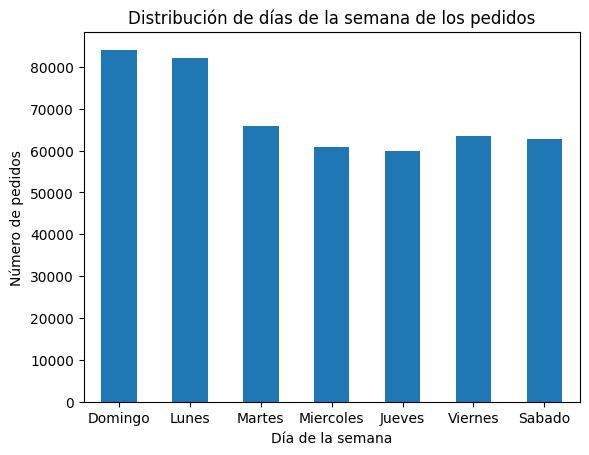

In [57]:
dow_map = {
    0: 'Domingo',
    1: 'Lunes',
    2: 'Martes',
    3: 'Miercoles',
    4: 'Jueves',
    5: 'Viernes',
    6: 'Sabado'
}

orders_datetime['order_dow'].map(dow_map).value_counts().reindex([dow_map[i] for i in range(7)], fill_value=0).plot(
    kind='bar',
    title='Distribución de días de la semana de los pedidos',
    xlabel='Día de la semana',
    ylabel='Número de pedidos',
    rot=0,
)

<Axes: title={'center': 'Distribución de horas del día de los pedidos'}, xlabel='Hora del día', ylabel='Número de pedidos'>

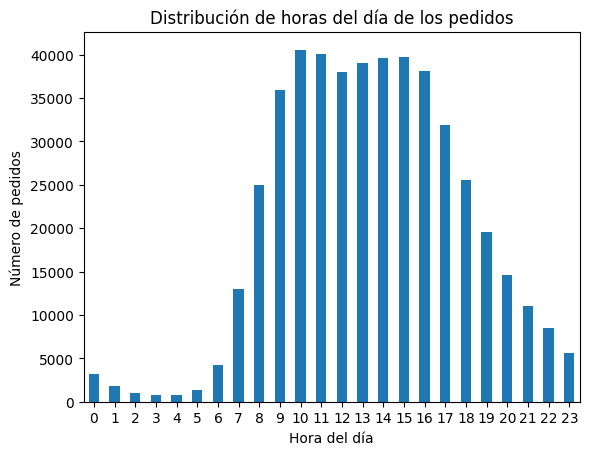

In [58]:
orders_datetime['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar',
    title='Distribución de horas del día de los pedidos',
    xlabel='Hora del día',
    ylabel='Número de pedidos',
    rot=0,
)

<Axes: title={'center': 'Distribución de horas del día de los pedidos por día de la semana'}, xlabel='Hora del día', ylabel='Número de pedidos'>

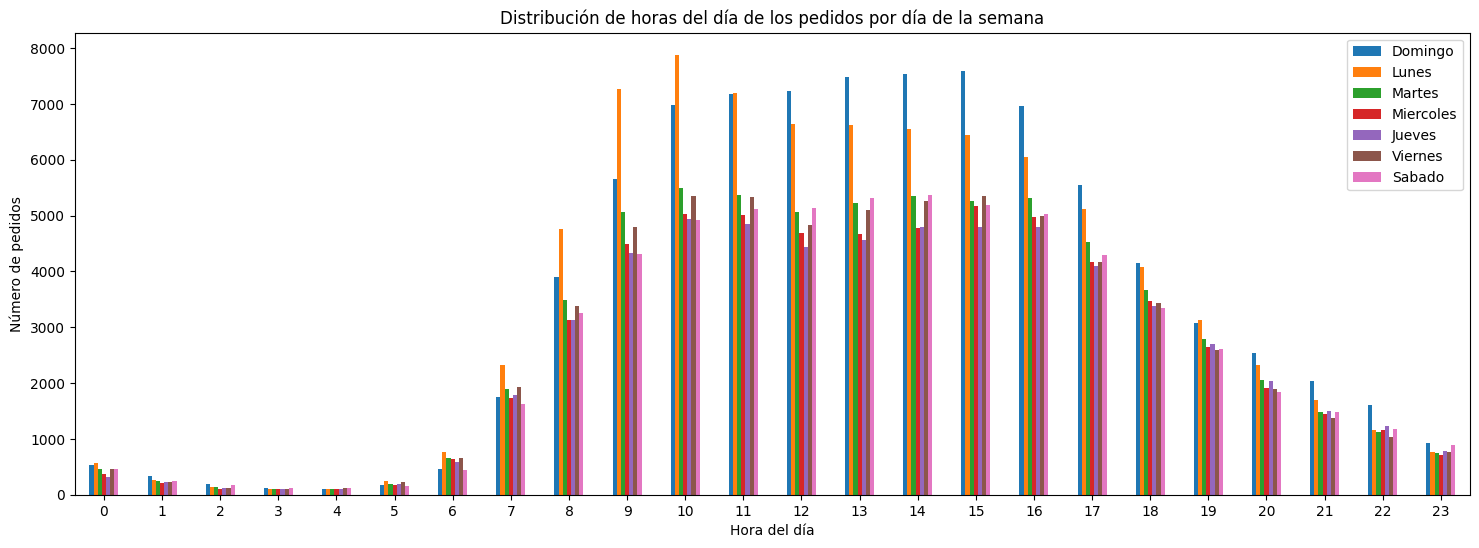

In [59]:
orders_hour_in_dow = pd.concat(
    [orders_datetime[orders_datetime['order_dow'] == i]['order_hour_of_day'].value_counts().sort_index() for i in range(7)], 
    axis=1)
orders_hour_in_dow.columns = [dow_map[i] for i in range(7)]
orders_hour_in_dow.plot(
    kind='bar',
    figsize=(18, 6),
    title='Distribución de horas del día de los pedidos por día de la semana',
    xlabel='Hora del día',
    ylabel='Número de pedidos',
    rot=0,
)

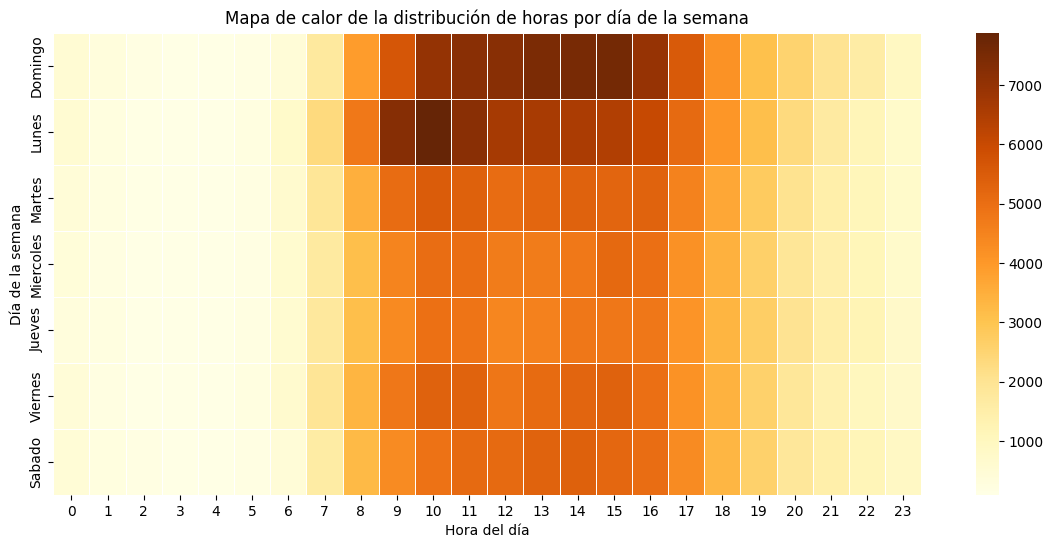

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(
    orders_hour_in_dow.T,
    cmap="YlOrBr",
    linewidths=0.5
)

plt.title('Mapa de calor de la distribución de horas por día de la semana')
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.show()

<Axes: title={'center': 'Distribución de pedidos por hora: Miércoles vs Sábado'}, xlabel='Hora del día', ylabel='Número de pedidos'>

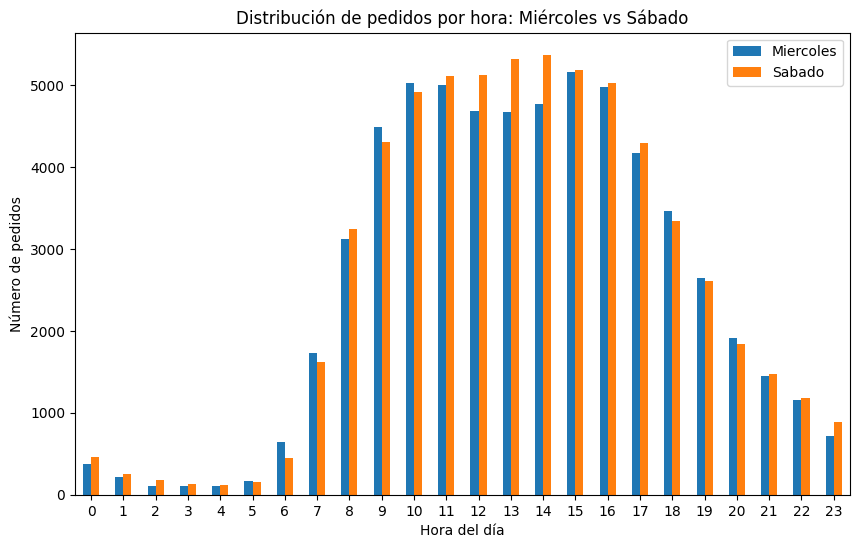

In [61]:
orders_hour_in_dow[['Miercoles', 'Sabado']].plot(
    kind='bar',
    figsize=(10, 6),
    title='Distribución de pedidos por hora: Miércoles vs Sábado',
    xlabel='Hora del día',
    ylabel='Número de pedidos',
    rot=0,
)

**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

In [62]:
days_since_prior_order = obt[['order_id', 'days_since_prior_order']].drop_duplicates()

# Eliminamos los valores nulos (que ya imputamos con -1) para el análisis de sensibilidad, ya que no representan un valor real de días desde el último pedido.
days_since_prior_order = days_since_prior_order[days_since_prior_order['days_since_prior_order'] >= 0]

# Convertimos a entero para facilitar el análisis, ya que los valores son números enteros representando días.
days_since_prior_order['days_since_prior_order'] = days_since_prior_order['days_since_prior_order'].astype(int)

display(days_since_prior_order.info())
display(days_since_prior_order.describe().iloc[1:])
display(days_since_prior_order.head())

<class 'pandas.core.frame.DataFrame'>
Index: 450135 entries, 0 to 4573896
Data columns (total 2 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   order_id                450135 non-null  int64
 1   days_since_prior_order  450135 non-null  int64
dtypes: int64(2)
memory usage: 10.3 MB


None

,order_id,days_since_prior_order
mean,1.710136e+06,11.101814
std,9.868957e+05,9.190004
min,4.000000e+00,0.000000
25%,8.568045e+05,4.000000
50%,1.709565e+06,7.000000
75%,2.563420e+06,15.000000
max,3.421079e+06,30.000000


,order_id,days_since_prior_order
0,1515936,30
13,1690866,9
19,1454967,2
25,1768857,10
41,3007858,17


<Axes: title={'center': 'Distribución de días desde el último pedido'}, xlabel='Días desde el último pedido', ylabel='Número de pedidos'>

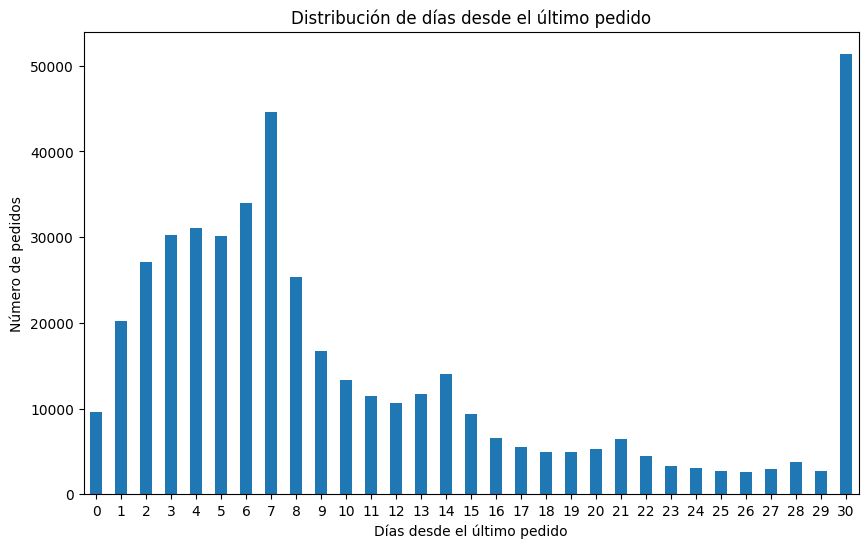

In [63]:
days_since_prior_order['days_since_prior_order'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title='Distribución de días desde el último pedido',
    xlabel='Días desde el último pedido',
    ylabel='Número de pedidos',
    rot=0,
)

In [64]:
# Moda

print(f'Moda de días desde el último pedido: {days_since_prior_order["days_since_prior_order"].mode()[0]}')

Moda de días desde el último pedido: 30


In [65]:
# Asimetría

print(f'Asimetría de días desde el último pedido: {days_since_prior_order["days_since_prior_order"].skew()}')

Asimetría de días desde el último pedido: 0.9899358029182349


### Hallazgos estadísticos del grupo A
La distribución de `order_dow` es coherente con un patrón real de compras: la demanda es más alta en domingo y lunes, y luego se mantiene más estable entre martes y sábado. En `order_hour_of_day` se observa una concentración clara entre las 8 y las 18 horas, con pico entre media mañana y la tarde; la actividad es muy baja de madrugada.
Al comparar miércoles vs. sábado, la forma general es muy parecida: ambos días concentran pedidos entre 9 y 17 horas, con diferencias pequeñas en algunos picos horarios, pero sin cambios estructurales fuertes. En otras palabras, sí hay variación por día, pero el comportamiento horario global se conserva.
El tiempo entre órdenes presenta una asimetría positiva (`skew = 0.99`): la mediana es de 7 días, la media es de 11.1 días y la moda está en 30 días. Esto indica una concentración importante en periodos cortos de recompra, pero con una cola hacia esperas más largas; además, el pico en 30 días sugiere una recurrencia mensual relevante o un posible error en los datos de más de 30 días limitados a este valor.

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

In [66]:
number_of_orders = obt.groupby('user_id').agg(total_orders=('order_id', 'nunique')).reset_index()

number_of_orders.head()

,user_id,total_orders
0,2,2
1,4,2
2,5,1
3,6,2
4,7,2


,total_orders
count,157437.000000
mean,3.042182
std,2.746842
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
90%,6.000000
95%,9.000000
99%,14.000000


IQR (Q3 - Q1): 3.00
Coeficiente de variacion: 0.90
Asimetria (skewness): 2.27
Percentil 95 de total_orders: 9.00
Clientes extra-leales (>= P95): 8479 de 157437 (5.39%)
Participacion de compras del top 5% de clientes: 19.35%


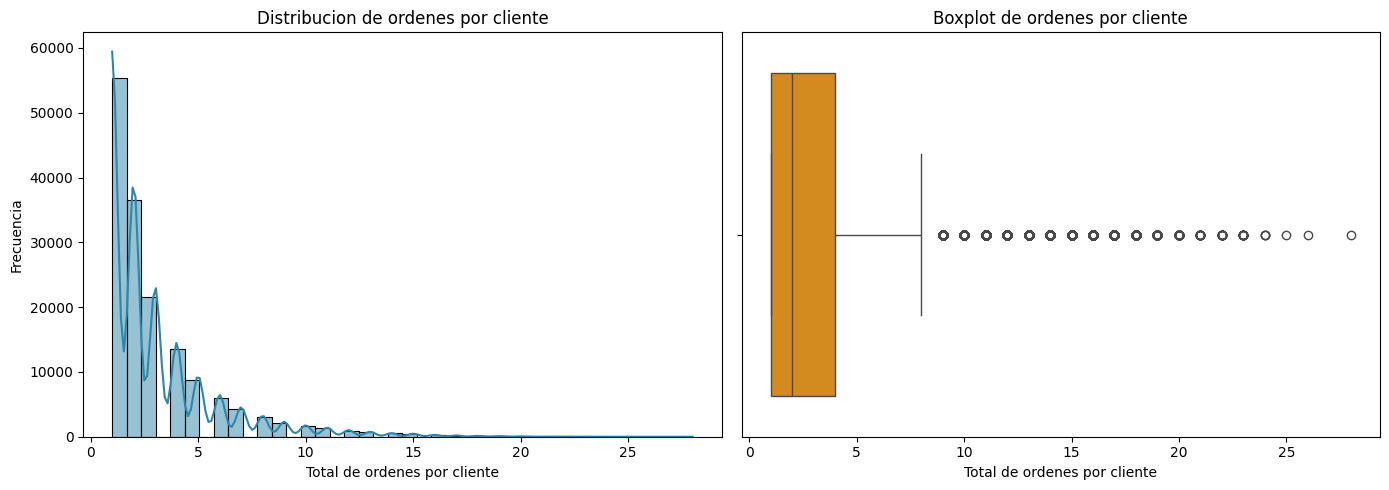

,user_id,total_orders
114085,149605,28
147428,193164,26
59737,78375,25
112979,148162,24
50752,66664,24
102607,134511,24
87672,114835,23
148129,194051,23
35734,46864,23
81602,106869,23


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Distribucion de compras por cliente
orders_per_user = number_of_orders['total_orders']

summary_stats = orders_per_user.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('total_orders')
display(summary_stats)

# Metricas de dispersion y cola
iqr_orders = orders_per_user.quantile(0.75) - orders_per_user.quantile(0.25)
cv_orders = orders_per_user.std() / orders_per_user.mean()
skew_orders = orders_per_user.skew()

q95 = orders_per_user.quantile(0.95)
extra_loyal_clients = number_of_orders[number_of_orders['total_orders'] >= q95]

# Participacion de compras del top 5% de clientes
top_5_threshold = int(np.ceil(len(number_of_orders) * 0.05))
top_5_clients = number_of_orders.nlargest(top_5_threshold, 'total_orders')
share_top_5 = top_5_clients['total_orders'].sum() / number_of_orders['total_orders'].sum()

print(f"IQR (Q3 - Q1): {iqr_orders:.2f}")
print(f"Coeficiente de variacion: {cv_orders:.2f}")
print(f"Asimetria (skewness): {skew_orders:.2f}")
print(f"Percentil 95 de total_orders: {q95:.2f}")
print(f"Clientes extra-leales (>= P95): {extra_loyal_clients.shape[0]} de {number_of_orders.shape[0]} ({extra_loyal_clients.shape[0]/number_of_orders.shape[0]:.2%})")
print(f"Participacion de compras del top 5% de clientes: {share_top_5:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(orders_per_user, bins=40, kde=True, ax=axes[0], color='#2E86AB')
axes[0].set_title('Distribucion de ordenes por cliente')
axes[0].set_xlabel('Total de ordenes por cliente')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=orders_per_user, ax=axes[1], color='#F18F01')
axes[1].set_title('Boxplot de ordenes por cliente')
axes[1].set_xlabel('Total de ordenes por cliente')

plt.tight_layout()
plt.show()

display(extra_loyal_clients.sort_values('total_orders', ascending=False).head(10))

**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

In [68]:
orders_per_product = (
    obt.groupby(['product_id', 'product_name', 'aisle'])
       .agg(total_orders=('order_id', 'nunique'),
            total_reorders=('reordered', lambda x: (x == 1).sum()))
       .reset_index()
)

orders_per_product = orders_per_product[orders_per_product['product_id'] != -1]
orders_per_product.head()

,product_id,product_name,aisle,total_orders,total_reorders
1,1.0,Chocolate Sandwich Cookies,cookies cakes,280,158
2,2.0,All-Seasons Salt,spices seasonings,11,0
3,3.0,Robust Golden Unsweetened Oolong Tea,tea,42,31
4,4.0,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,49,25
5,7.0,Pure Coconut Water With Orange,juice nectars,2,1


In [69]:
# verifica si un mismo product_id está en 2 o más aisles

product_aisle_counts = orders_per_product.groupby('product_id')['aisle'].nunique()
products_with_multiple_aisles = product_aisle_counts[product_aisle_counts > 1].index
print(f'Número de productos con múltiples pasillos: {len(products_with_multiple_aisles)}')

Número de productos con múltiples pasillos: 0


In [70]:
top_20_products = orders_per_product.sort_values('total_orders', ascending=False).head(20)
display(top_20_products)

,product_id,product_name,aisle,total_orders,total_reorders
22809,24852.0,Banana,fresh fruits,66050,55763
12026,13176.0,Bag of Organic Bananas,fresh fruits,53297,44450
19371,21137.0,Organic Strawberries,fresh fruits,37039,28639
20078,21903.0,Organic Baby Spinach,packaged vegetables fruits,33971,26233
43272,47209.0,Organic Hass Avocado,fresh fruits,29773,23629
43789,47766.0,Organic Avocado,fresh fruits,24689,18743
43664,47626.0,Large Lemon,fresh fruits,21495,15044
15365,16797.0,Strawberries,fresh fruits,20018,13945
24048,26209.0,Limes,fresh fruits,19690,13327
25557,27845.0,Organic Whole Milk,milk,19600,16251


,n_products,total_orders,total_reorders,mean_reorder_ratio,weighted_reorder_ratio,flag_is_in_top_20
aisle,,,,,,
milk,137,123943,97148,0.710771,0.783812,True
water seltzer sparkling water,149,114593,84133,0.698533,0.734190,False
fresh fruits,199,508027,365600,0.534671,0.719647,True
eggs,87,63079,44652,0.683693,0.707874,False
soy lactosefree,139,87130,60720,0.647736,0.696890,False
yogurt,433,194845,134611,0.653301,0.690862,False
cream,66,43193,29828,0.614760,0.690575,False
packaged produce,30,39017,26858,0.602246,0.688367,False
bread,215,77481,52568,0.644729,0.678463,False


Asociación pasillo -> reorder_ratio (eta^2): 0.5103


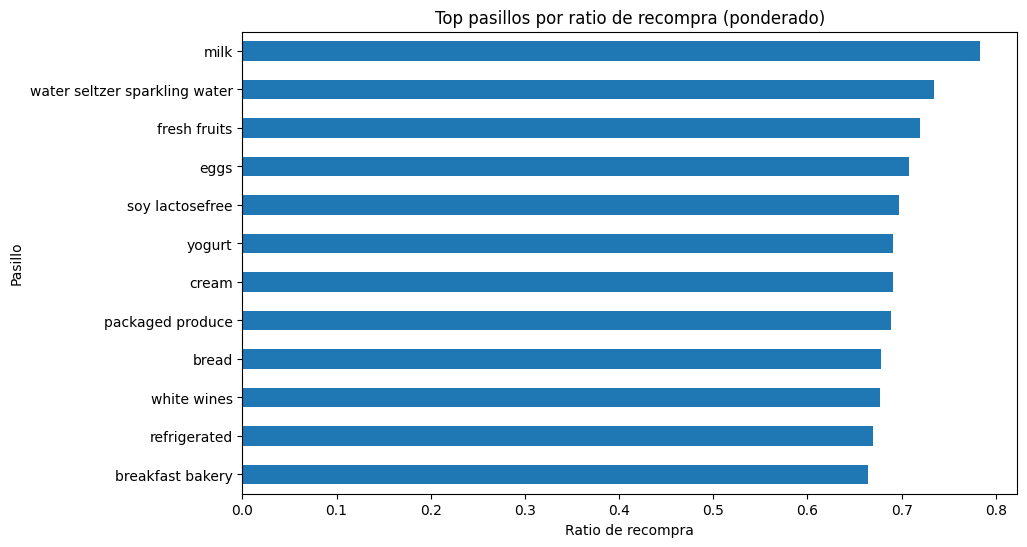

In [71]:
# Ratio de recompra por producto
orders_per_product = orders_per_product.assign(
    reorder_ratio=orders_per_product['total_reorders'] / orders_per_product['total_orders']
)

# Evitamos sesgo por productos con muy pocas órdenes
stable_products = orders_per_product[orders_per_product['total_orders'] >= 50].copy()

# Métricas por pasillo (incluye ratio ponderado por volumen)
aisle_reorder = (
    stable_products.groupby('aisle')
    .agg(
        n_products=('product_id', 'count'),
        total_orders=('total_orders', 'sum'),
        total_reorders=('total_reorders', 'sum'),
        mean_reorder_ratio=('reorder_ratio', 'mean')
    )
    .assign(
        weighted_reorder_ratio=lambda x: x['total_reorders'] / x['total_orders'],
        flag_is_in_top_20=lambda x: x.index.isin(top_20_products['aisle'])
    )
    .sort_values('weighted_reorder_ratio', ascending=False)
)

display(aisle_reorder.head(15))

# "Fuerza" de asociación pasillo -> ratio de recompra (eta^2)
overall_mean = stable_products['reorder_ratio'].mean()
group_stats = stable_products.groupby('aisle')['reorder_ratio'].agg(['count', 'mean'])
ss_between = ((group_stats['mean'] - overall_mean) ** 2 * group_stats['count']).sum()
ss_total = ((stable_products['reorder_ratio'] - overall_mean) ** 2).sum()
eta_squared = ss_between / ss_total if ss_total > 0 else np.nan

print(f"Asociación pasillo -> reorder_ratio (eta^2): {eta_squared:.4f}")

top_aisles = aisle_reorder.head(12).sort_values('weighted_reorder_ratio', ascending=True)
ax = top_aisles['weighted_reorder_ratio'].plot(
    kind='barh',
    figsize=(10, 6),
    title='Top pasillos por ratio de recompra (ponderado)',
    xlabel='Ratio de recompra',
    ylabel='Pasillo'
)

### Conclusiones sobre el perfil del carrito [Grupo B]:

En B1, al agrupar por cliente (`total_orders`), la distribución es claramente asimétrica a la derecha (cola larga):
- Media: **3.04** órdenes por cliente
- Mediana: **2** órdenes
- IQR: **3** (Q1=1, Q3=4)
- Percentil 95: **9** órdenes
- Máximo observado: **28** órdenes
- Asimetría: **2.27**

Estos indicadores muestran alta heterogeneidad entre clientes: la mayoría compra pocas veces, pero existe un subconjunto pequeño con mucha mayor recurrencia.

Sí existen colas largas de clientes extra-leales. Tomando como umbral el P95 (clientes con 9 o más órdenes), se identifica un grupo de **8,479 clientes** (aprox. **5.39%** del total) que concentra **19.35%** de todas las órdenes. Esto confirma un patrón de retención desigual, con una minoría de clientes aportando una fracción desproporcionada de la actividad.

En B2, el patrón de Pareto se observa en dos niveles: concentración de demanda en pocos productos y concentración de recompra en pasillos específicos. Primero, la validación de consistencia muestra que **no hay productos asignados a múltiples pasillos** (0 casos), lo que reduce ambiguedad en la lectura por categoría y fortalece la interpretación del análisis.

Segundo, al comparar la recompra por pasillo con productos estables (>=50 órdenes), los mayores ratios ponderados se ubican en categorías de consumo recurrente (por ejemplo, *milk*, *water seltzer sparkling water*, *fresh fruits*, *eggs*, *yogurt* y *cream*), con valores visualmente alrededor de **0.66 a 0.78**. Esto sugiere que la recompra no responde solo a popularidad puntual, sino a hábitos de reposición en bienes de alta rotación doméstica.

Finalmente, la métrica de asociación reporta **eta^2 = 0.5103** entre pasillo y `reorder_ratio`, un tamaño de efecto considerable para este contexto exploratorio. En términos analíticos, esto indica que la categoría del producto explica una porción importante de la variabilidad en recompra; sin embargo, no la explica por completo, por lo que variables de cliente (frecuencia, lealtad, ciclo de consumo) siguen siendo necesarias para un modelo más robusto de recurrencia.

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

Resumen tamaño de canasta (items por pedido):


,items_per_order
count,450046.000000
mean,10.098983
std,7.540206
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
90%,20.000000
95%,25.000000
99%,35.000000


Promedio de artículos por pedido: 10.10
Mediana de artículos por pedido: 8.00
Curtosis (Fisher, exceso): 4.13
Curtosis (Pearson): 7.13


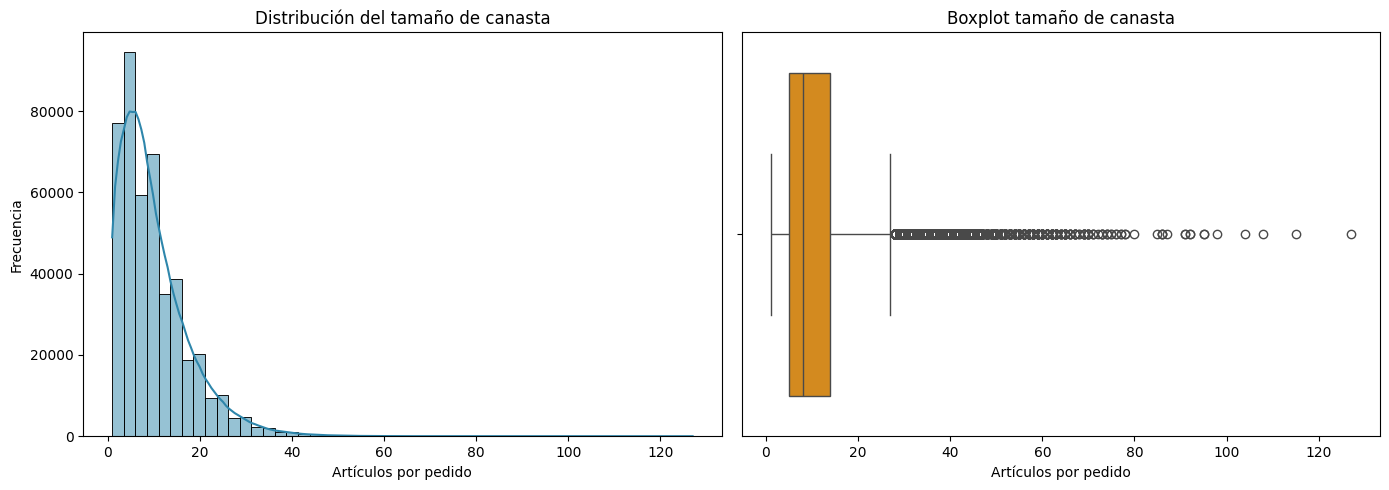

In [72]:
# 1) Tamaño de canasta por pedido
# Excluimos product_id = -1 (valor imputado para órdenes sin detalle de producto)
basket_size = (
    obt[obt["product_id"] != -1]
    .groupby("order_id")
    .size()
    .rename("items_per_order")
    .reset_index()
)

# 2) Estadísticos principales
stats = basket_size["items_per_order"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
mean_items = basket_size["items_per_order"].mean()
median_items = basket_size["items_per_order"].median()
kurt_excess = basket_size["items_per_order"].kurt()   # curtosis de Fisher (exceso)
kurt_pearson = kurt_excess + 3                        # curtosis de Pearson

print("Resumen tamaño de canasta (items por pedido):")
display(stats.to_frame("items_per_order"))

print(f"Promedio de artículos por pedido: {mean_items:.2f}")
print(f"Mediana de artículos por pedido: {median_items:.2f}")
print(f"Curtosis (Fisher, exceso): {kurt_excess:.2f}")
print(f"Curtosis (Pearson): {kurt_pearson:.2f}")

# 3) Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(basket_size["items_per_order"], bins=50, kde=True, ax=axes[0], color="#2E86AB")
axes[0].set_title("Distribución del tamaño de canasta")
axes[0].set_xlabel("Artículos por pedido")
axes[0].set_ylabel("Frecuencia")

sns.boxplot(x=basket_size["items_per_order"], ax=axes[1], color="#F18F01")
axes[1].set_title("Boxplot tamaño de canasta")
axes[1].set_xlabel("Artículos por pedido")

plt.tight_layout()
plt.show()

**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

,product_id,product_name,appearances,first_count,first_share,reorder_rate
22808,24852.0,Banana,66046,15562,0.235624,0.844275
12025,13176.0,Bag of Organic Bananas,53295,11026,0.206886,0.833999
25556,27845.0,Organic Whole Milk,19600,4363,0.222602,0.829133
19370,21137.0,Organic Strawberries,37035,3946,0.106548,0.773242
43270,47209.0,Organic Hass Avocado,29772,3390,0.113865,0.793632
20077,21903.0,Organic Baby Spinach,33970,3336,0.098204,0.772211
43787,47766.0,Organic Avocado,24689,3044,0.123294,0.759164
18018,19660.0,Spring Water,7675,2336,0.304365,0.810814
15364,16797.0,Strawberries,20017,2308,0.115302,0.696608
25666,27966.0,Organic Raspberries,19194,2024,0.105450,0.768313


Correlación Pearson (first_share vs reorder_rate) [Top20]: 0.6685
Correlación Spearman (first_share vs reorder_rate) [Top20]: 0.7038

Matriz de correlación Pearson (Top20):


,appearances,first_count,first_share,reorder_rate
appearances,1.000000,0.896872,-0.181421,0.264372
first_count,0.896872,1.000000,0.207940,0.515734
first_share,-0.181421,0.207940,1.000000,0.668478
reorder_rate,0.264372,0.515734,0.668478,1.000000


Matriz de correlación Spearman (Top20):


,appearances,first_count,first_share,reorder_rate
appearances,1.000000,0.739850,-0.415038,-0.007519
first_count,0.739850,1.000000,0.177444,0.481203
first_share,-0.415038,0.177444,1.000000,0.703759
reorder_rate,-0.007519,0.481203,0.703759,1.000000


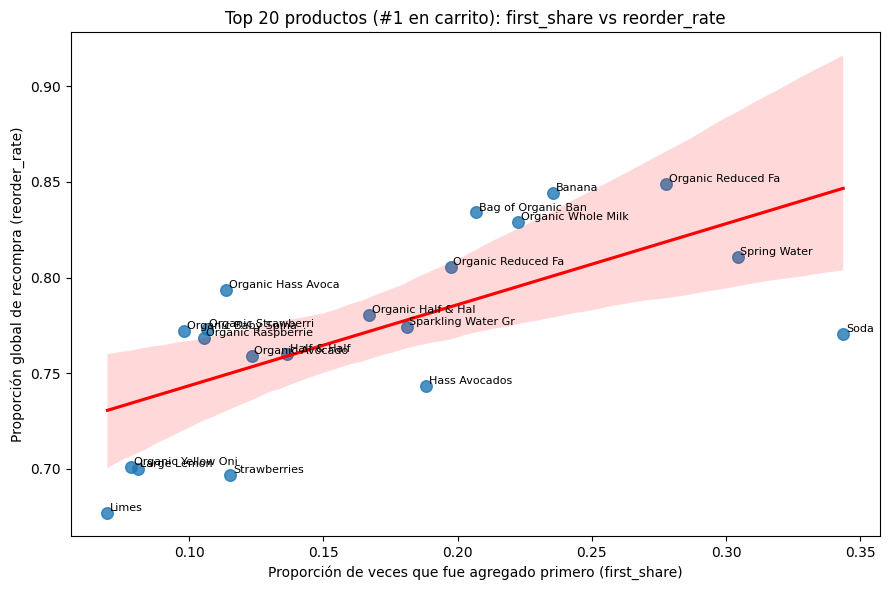

In [73]:
# Base válida para C2 (quitamos imputados)
c2 = obt[
    (obt["product_id"] != -1) &
    (obt["add_to_cart_order"] != -1) &
    (obt["reordered"].isin([0, 1]))
].copy()

c2["is_first"] = (c2["add_to_cart_order"] == 1).astype(int)

# Métricas por producto
product_metrics = (
    c2.groupby(["product_id", "product_name"], as_index=False)
      .agg(
          appearances=("order_id", "count"),
          first_count=("is_first", "sum"),
          first_share=("is_first", "mean"),
          reorder_rate=("reordered", "mean")
      )
)

# Top 20 productos más frecuentes en posición #1
top20_first = product_metrics.nlargest(20, "first_count").copy()

display(top20_first[["product_id", "product_name", "appearances", "first_count", "first_share", "reorder_rate"]])

# Correlaciones (Pearson y Spearman) en el top 20
pearson_r = top20_first["first_share"].corr(top20_first["reorder_rate"], method="pearson")
spearman_r = top20_first["first_share"].corr(top20_first["reorder_rate"], method="spearman")

print(f"Correlación Pearson (first_share vs reorder_rate) [Top20]: {pearson_r:.4f}")
print(f"Correlación Spearman (first_share vs reorder_rate) [Top20]: {spearman_r:.4f}")

corr_pearson = top20_first[["appearances", "first_count", "first_share", "reorder_rate"]].corr(method="pearson")
corr_spearman = top20_first[["appearances", "first_count", "first_share", "reorder_rate"]].corr(method="spearman")

print("\nMatriz de correlación Pearson (Top20):")
display(corr_pearson)

print("Matriz de correlación Spearman (Top20):")
display(corr_spearman)

# Scatter + línea de tendencia
plt.figure(figsize=(9, 6))
sns.regplot(
    data=top20_first,
    x="first_share",
    y="reorder_rate",
    scatter_kws={"s": 70, "alpha": 0.8},
    line_kws={"color": "red"}
)

# Etiquetas de productos
for _, row in top20_first.iterrows():
    plt.text(row["first_share"] + 0.001, row["reorder_rate"] + 0.001, str(row["product_name"])[:18], fontsize=8)

plt.title("Top 20 productos (#1 en carrito): first_share vs reorder_rate")
plt.xlabel("Proporción de veces que fue agregado primero (first_share)")
plt.ylabel("Proporción global de recompra (reorder_rate)")
plt.tight_layout()
plt.show()

**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

In [74]:
c3_base = obt[
    (obt["product_id"] != -1) &
    (obt["reordered"].isin([0, 1]))
].copy()

reorder_by_product = (
    c3_base.groupby(["product_id", "product_name"], as_index=False)
    .agg(
        total_compras=("order_id", "count"),
        total_recompras=("reordered", "sum")
    )
    .assign(
        proporcion_recompra=lambda x: x["total_recompras"] / x["total_compras"]
    )
    .sort_values("proporcion_recompra", ascending=False)
)

min_compras_estables = 50
reorder_by_product_stable = reorder_by_product[
    reorder_by_product["total_compras"] >= min_compras_estables
].copy()

print("Muestra de proporción de re-compras por producto (sin filtro):")
display(reorder_by_product.head(20))

print(f"Muestra de proporción de re-compras por producto (>= {min_compras_estables} compras):")
display(reorder_by_product_stable.head(20))

print("Resumen estadístico de la proporción de re-compra por producto (sin filtro):")
display(reorder_by_product["proporcion_recompra"].describe())

print("Resumen estadístico de la proporción de re-compra por producto (productos estables):")
display(reorder_by_product_stable["proporcion_recompra"].describe())

Muestra de proporción de re-compras por producto (sin filtro):


,product_id,product_name,total_compras,total_recompras,proporcion_recompra
28108,30644.0,Organic French Roast,2,2.0,1.0
7340,8054.0,Bissli Smokey Wheat Snacks,1,1.0,1.0
28114,30650.0,Mushroom Lover's Veggie Burgers,2,2.0,1.0
41002,44747.0,Frozen Organic Blackberries,1,1.0,1.0
40998,44743.0,Real Zero Cola,2,2.0,1.0
32921,35897.0,Ham Hock,1,1.0,1.0
32861,35834.0,Bulgarian Organic Yogurt,2,2.0,1.0
2684,2939.0,Cheddar Crunchin' Crackers,7,7.0,1.0
20357,22209.0,Temples Earl Gray Strong Tea,2,2.0,1.0
20361,22213.0,2% Reduced Fat Chocolate Milk,2,2.0,1.0


Muestra de proporción de re-compras por producto (>= 50 compras):


,product_id,product_name,total_compras,total_recompras,proporcion_recompra
44045,48041.0,DanActive Vanilla Probiotic Dairy Drink,65,59.0,0.907692
30242,32978.0,Lemon Lime Seltzer,66,59.0,0.893939
36458,39782.0,Organic Raspberry Mate Energy Drink,65,58.0,0.892308
15984,17469.0,Lo-Carb Energy Drink,63,56.0,0.888889
22943,25000.0,Whole Wheat Multigrain Pop Cakes,53,47.0,0.886792
44092,48095.0,Purified Water- 9.5pH+,57,50.0,0.877193
8483,9292.0,Half And Half Ultra Pasteurized,397,348.0,0.876574
2450,2677.0,Yerba Mate Sparkling Classic Gold,171,149.0,0.871345
43292,47231.0,Ultra-Purified Water,205,178.0,0.868293
1046,1157.0,Wheat Sandwich Bread,147,127.0,0.863946


Resumen estadístico de la proporción de re-compra por producto (sin filtro):


count    45573.000000
mean         0.386707
std          0.272132
min          0.000000
25%          0.166667
50%          0.408163
75%          0.575758
max          1.000000
Name: proporcion_recompra, dtype: float64

Resumen estadístico de la proporción de re-compra por producto (productos estables):


count    10364.000000
mean         0.520285
std          0.150764
min          0.010989
25%          0.427331
50%          0.538462
75%          0.630435
max          0.907692
Name: proporcion_recompra, dtype: float64

**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

In [75]:
c4_base = obt[
    (obt["product_id"] != -1) &
    (obt["reordered"].isin([0, 1]))
].copy()

reorder_by_user = (
    c4_base.groupby("user_id", as_index=False)
    .agg(
        total_compras=("order_id", "count"),
        total_recompras=("reordered", "sum")
    )
    .assign(
        proporcion_recompra=lambda x: x["total_recompras"] / x["total_compras"]
    )
    .sort_values("proporcion_recompra", ascending=False)
)

min_compras_estables_usuario = 50
reorder_by_user_stable = reorder_by_user[
    reorder_by_user["total_compras"] >= min_compras_estables_usuario
].copy()

print("Muestra de proporción de re-compras por usuario (sin filtro):")
display(reorder_by_user.head(20))

print(f"Muestra de proporción de re-compras por usuario (>= {min_compras_estables_usuario} compras):")
display(reorder_by_user_stable.head(20))

print("Resumen estadístico de la proporción de re-compra por usuario (sin filtro):")
display(reorder_by_user["proporcion_recompra"].describe())

print("Resumen estadístico de la proporción de re-compra por usuario (usuarios estables):")
display(reorder_by_user_stable["proporcion_recompra"].describe())

Muestra de proporción de re-compras por usuario (sin filtro):


,user_id,total_compras,total_recompras,proporcion_recompra
149589,206164,1,1.0,1.0
13072,17973,2,2.0,1.0
142827,196795,6,6.0,1.0
142825,196792,9,9.0,1.0
142824,196791,17,17.0,1.0
13127,18048,7,7.0,1.0
12980,17849,1,1.0,1.0
142802,196759,17,17.0,1.0
98293,135680,3,3.0,1.0
98685,136211,1,1.0,1.0


Muestra de proporción de re-compras por usuario (>= 50 compras):


,user_id,total_compras,total_recompras,proporcion_recompra
135557,186894,65,65.0,1.000000
111771,154246,51,51.0,1.000000
28415,39245,76,76.0,1.000000
132834,183159,54,54.0,1.000000
9881,13548,52,52.0,1.000000
64358,88822,58,58.0,1.000000
131516,181347,51,51.0,1.000000
59721,82414,51,51.0,1.000000
59038,81466,56,56.0,1.000000
130265,179684,78,78.0,1.000000


Resumen estadístico de la proporción de re-compra por usuario (sin filtro):


count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: proporcion_recompra, dtype: float64

Resumen estadístico de la proporción de re-compra por usuario (usuarios estables):


count    26604.000000
mean         0.657457
std          0.172785
min          0.000000
25%          0.550000
50%          0.681818
75%          0.787611
max          1.000000
Name: proporcion_recompra, dtype: float64

**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

In [76]:
# C5 usando resultado de C2 (top20_first ya existe)

c5_top20 = top20_first[[
    "product_id", "product_name", "first_count", "first_share", "reorder_rate"
]].rename(columns={
    "first_count": "veces_primero",
    "first_share": "proporcion_primero",
    "reorder_rate": "proporcion_recompra_global"
}).sort_values("veces_primero", ascending=False).reset_index(drop=True)

print("Top 20 productos que los clientes ponen primero en sus carritos:")
display(c5_top20)

Top 20 productos que los clientes ponen primero en sus carritos:


,product_id,product_name,veces_primero,proporcion_primero,proporcion_recompra_global
0,24852.0,Banana,15562,0.235624,0.844275
1,13176.0,Bag of Organic Bananas,11026,0.206886,0.833999
2,27845.0,Organic Whole Milk,4363,0.222602,0.829133
3,21137.0,Organic Strawberries,3946,0.106548,0.773242
4,47209.0,Organic Hass Avocado,3390,0.113865,0.793632
5,21903.0,Organic Baby Spinach,3336,0.098204,0.772211
6,47766.0,Organic Avocado,3044,0.123294,0.759164
7,19660.0,Spring Water,2336,0.304365,0.810814
8,16797.0,Strawberries,2308,0.115302,0.696608
9,27966.0,Organic Raspberries,2024,0.105450,0.768313


### Tus conclusiones avanzadas [Grupo C]:
(Enuncia las posibles relaciones matemáticas encontradas o variables dispersas)

En el **Grupo C** se observan patrones consistentes entre tamaño de canasta, orden de exposición y recompra:

- **C1 (Tamaño de canasta):** la distribución de artículos por pedido es asimétrica a la derecha. La media supera a la mediana y la curtosis evidencia concentración en canastas pequeñas/medias con una cola de pedidos grandes. Esto sugiere un comportamiento típico de compra frecuente con pocos casos de alto volumen.
- **C2 (Primer producto vs fidelidad):** en el top 20 de productos agregados primero, la relación entre `first_share` y `reorder_rate` es positiva pero no perfecta (según Pearson/Spearman). Ser agregado primero se asocia con recurrencia, pero no determina por sí solo la recompra.
- **C3 (Recompra por producto):** sin filtro aparecen proporciones extremas por baja base de observaciones; al aplicar estabilidad (p. ej., mínimo de compras), la métrica se vuelve más robusta y permite identificar productos realmente recurrentes.
- **C4 (Recompra por usuario):** existe alta heterogeneidad entre clientes; algunos concentran proporciones de recompra muy altas (hábitos estables) y otros muestran menor recurrencia (compra más exploratoria o eventual).
- **C5 (Top 20 en primera posición):** el ranking de productos que se agregan primero confirma un patrón de “productos ancla” del carrito, coherente con categorías de reposición frecuente.

En conjunto, los resultados indican que la recompra está explicada por una combinación de **tipo de producto**, **hábito individual del usuario** y **posición temprana en el carrito**. Operativamente, esto respalda estrategias de recordatorios de reposición, promociones personalizadas para clientes de baja recurrencia y priorización de inventario en productos ancla.

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.

Luego de la auditoría de calidad y la construcción de la OBT, el conjunto de datos alcanza un nivel de confiabilidad adecuado para sustentar decisiones de negocio: se corrigieron duplicados explícitos, se preservó integridad referencial con imputaciones controladas (`Unknown` y `-1`) y se identificaron fallas de gobernanza relevantes (truncamiento de `add_to_cart_order` después de 64 ítems, concentración estructural de nulos en catálogo y posible tope de `days_since_prior_order` en 30); ya en negocio, la demanda muestra patrón realista (picos de compra en domingo/lunes y en franja diurna 8–18h), la recurrencia es **heterogénea y concentrada** (cola larga: mediana 2 órdenes por cliente, y $\approx 5.39 \%$ de clientes concentra $\approx 19.35\%$ de órdenes), y la recompra está explicada de forma importante por la **categoría/pasillo** (efecto alto, $\eta^2 \approx 0.5103$) junto con hábitos individuales; además, los productos que se agregan primero funcionan como **anclas de reposición** (asociación positiva, no perfecta, con recompra), por lo que se recomiendan tres frentes: priorización de inventario en categorías de alta recompra, campañas de reposición/personalización por segmento de lealtad, y fortalecimiento de controles de calidad upstream para evitar sesgos por truncamientos y nulos estructurales.